<a href="https://colab.research.google.com/github/ShantanuVT/codealpha_tasks/blob/main/Handwritten_Character_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q tensorflow-datasets


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import tensorflow_datasets as tfds

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: []


In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1] and add channel dimension
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("Train shape:", x_train.shape, "Test shape:", x_test.shape)
num_classes_mnist = 10


Train shape: (60000, 28, 28, 1) Test shape: (10000, 28, 28, 1)


In [ ]:
def build_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

mnist_model = build_cnn((28, 28, 1), num_classes_mnist)
mnist_model.compile(optimizer="adam",
                     loss="sparse_categorical_crossentropy",
                     metrics=["accuracy"])
mnist_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,306 (1.49 MB)

 Trainable params: 390,858 (1.49 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history_mnist = mnist_model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    callbacks=[early_stop],
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 143s 319ms/step - accuracy: 0.9468 - loss: 0.1840 - val_accuracy: 0.9353 - val_loss: 0.2087
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 126s 297ms/step - accuracy: 0.9817 - loss: 0.0587 - val_accuracy: 0.9890 - val_loss: 0.0358
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 126s 299ms/step - accuracy: 0.9873 - loss: 0.0428 - val_accuracy: 0.9887 - val_loss: 0.0360
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 126s 299ms/step - accuracy: 0.9891 - loss: 0.0346 - val_accuracy: 0.9895 - val_loss: 0.0362
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 123s 292ms/step - accuracy: 0.9909 - loss: 0.0289 - val_accuracy: 0.9930 - val_loss: 0.0277
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 144s 298ms/step - accuracy: 0.9926 - loss: 0.0245 - val_accuracy: 0.9927 - val_loss: 0.0303
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 124s 294ms/step - accuracy: 0.9936 - loss: 0.0207 - val_accuracy: 0.9890 - val_loss: 0.0471
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 126s 300ms/step - accuracy: 0.9936 -

In [ ]:
test_loss, test_acc = mnist_model.evaluate(x_test, y_test)
print(f"MNIST Test Accuracy: {test_acc * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9922 - loss: 0.0258
MNIST Test Accuracy: 99.22%


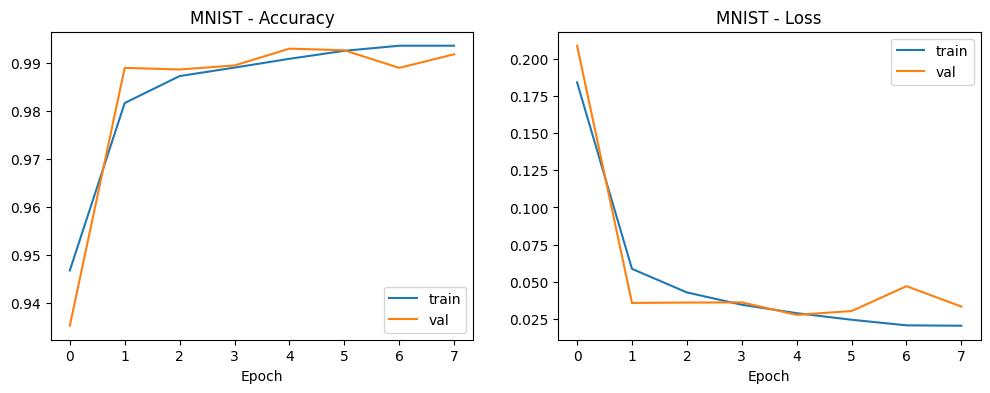

In [ ]:
def plot_history(history, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(history.history["accuracy"], label="train")
    ax[0].plot(history.history["val_accuracy"], label="val")
    ax[0].set_title(f"{title} - Accuracy")
    ax[0].set_xlabel("Epoch")
    ax[0].legend()

    ax[1].plot(history.history["loss"], label="train")
    ax[1].plot(history.history["val_loss"], label="val")
    ax[1].set_title(f"{title} - Loss")
    ax[1].set_xlabel("Epoch")
    ax[1].legend()
    plt.show()

plot_history(history_mnist, "MNIST")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


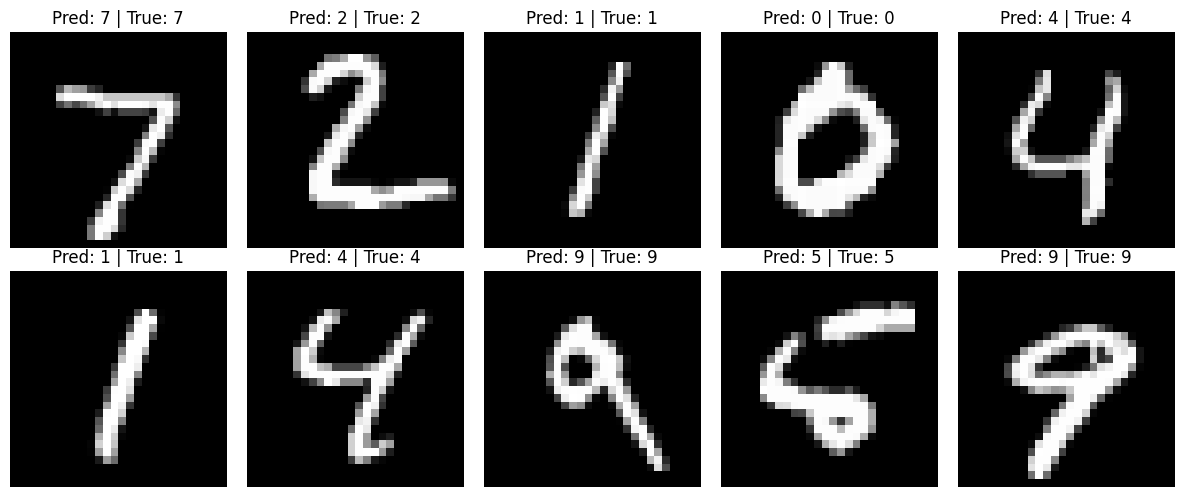

In [ ]:
preds = mnist_model.predict(x_test[:10])
pred_labels = np.argmax(preds, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_test[i].squeeze(), cmap="gray")
    ax.set_title(f"Pred: {pred_labels[i]} | True: {y_test[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
mnist_model.save("mnist_cnn_model.keras")
print("Saved mnist_cnn_model.keras")


Saved mnist_cnn_model.keras


Part 2 Character recoginition

In [ ]:
# To fix 'AttributeError: module 'tensorflow_datasets' has no attribute 'load''
# caused by a Protobuf VersionError during tfds import.
# After running this cell, please restart the Colab runtime (Runtime -> Restart runtime) for the changes to take effect.
!pip install --upgrade protobuf

emnist_train, emnist_test = tfds.load(
    "emnist/letters",
    split=["train", "test"],
    as_supervised=True,
)

num_classes_emnist = 27  # labels are 1-26 (A-Z); index 0 is left unused for simplicity

def preprocess_emnist(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    # EMNIST images come rotated/transposed relative to the usual MNIST orientation
    image = tf.image.flip_left_right(tf.image.rot90(image, k=3))
    return image, label

BATCH_SIZE = 128
emnist_train_ds = (
    emnist_train.map(preprocess_emnist)
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
emnist_test_ds = (
    emnist_test.map(preprocess_emnist)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Peek at one batch
for imgs, labels in emnist_train_ds.take(1):
    print("Batch image shape:", imgs.shape, "| Sample labels:", labels[:10].numpy())

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.7RB9H4_3.1.0/emnist-train.tfrecord-[0-9][0-9][0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.7RB9H4_3.1.0/emnist-test.tfrecord-[0-9][0-9][0-9…

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.
Batch image shape: (128, 28, 28, 1) | Sample labels: [12  1 14 11 11 10 13 25 16 14]


In [ ]:
emnist_model = build_cnn((28, 28, 1), num_classes_emnist)
emnist_model.compile(optimizer="adam",
                      loss="sparse_categorical_crossentropy",
                      metrics=["accuracy"])
emnist_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 27)             │         6,939 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 395,675 (1.51 MB)

 Trainable params: 395,227 (1.51 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
history_emnist = emnist_model.fit(
    emnist_train_ds,
    validation_data=emnist_test_ds,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
)


Epoch 1/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 236s 329ms/step - accuracy: 0.8343 - loss: 0.5348 - val_accuracy: 0.8994 - val_loss: 0.2739
Epoch 2/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 253s 317ms/step - accuracy: 0.9135 - loss: 0.2609 - val_accuracy: 0.9155 - val_loss: 0.2526
Epoch 3/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 258s 312ms/step - accuracy: 0.9270 - loss: 0.2166 - val_accuracy: 0.9195 - val_loss: 0.2273
Epoch 4/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 263s 313ms/step - accuracy: 0.9338 - loss: 0.1915 - val_accuracy: 0.9243 - val_loss: 0.2226
Epoch 5/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 220s 315ms/step - accuracy: 0.9394 - loss: 0.1723 - val_accuracy: 0.9259 - val_loss: 0.2300
Epoch 6/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 262s 315ms/step - accuracy: 0.9428 - loss: 0.1595 - val_accuracy: 0.9279 - val_loss: 0.2029
Epoch 7/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 220s 315ms/step - accuracy: 0.9467 - loss: 0.1477 - val_accuracy: 0.9299 - val_loss: 0.2112
Epoch 8/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 228s 328ms/step - accuracy: 0.9487 -

116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.9279 - loss: 0.2029
EMNIST Test Accuracy: 92.79%


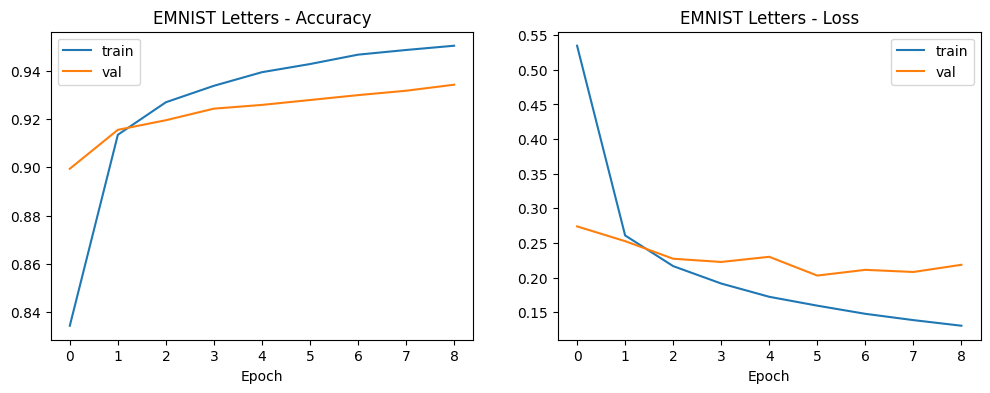

In [ ]:
test_loss_e, test_acc_e = emnist_model.evaluate(emnist_test_ds)
print(f"EMNIST Test Accuracy: {test_acc_e * 100:.2f}%")
plot_history(history_emnist, "EMNIST Letters")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


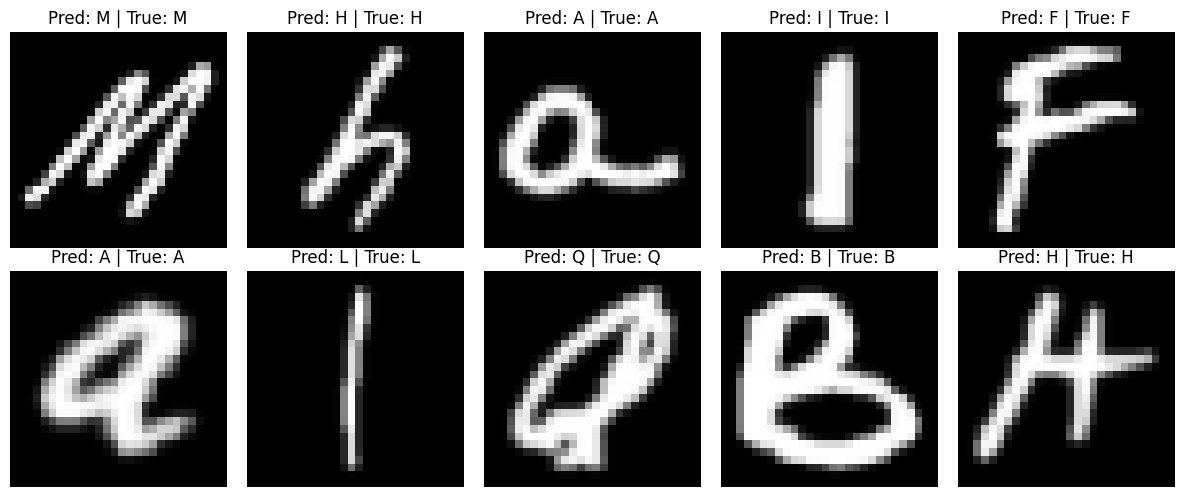

In [ ]:
import string

idx_to_letter = {i: letter for i, letter in enumerate(string.ascii_uppercase, start=1)}

sample_imgs, sample_labels = next(iter(emnist_test_ds))
preds_e = emnist_model.predict(sample_imgs[:10])
pred_labels_e = np.argmax(preds_e, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_imgs[i].numpy().squeeze(), cmap="gray")
    true_l = idx_to_letter.get(int(sample_labels[i].numpy()), "?")
    pred_l = idx_to_letter.get(int(pred_labels_e[i]), "?")
    ax.set_title(f"Pred: {pred_l} | True: {true_l}")
    ax.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
emnist_model.save("emnist_cnn_model.keras")
print("Saved emnist_cnn_model.keras")


Saved emnist_cnn_model.keras


Saving 15713178995.jpg to 15713178995.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


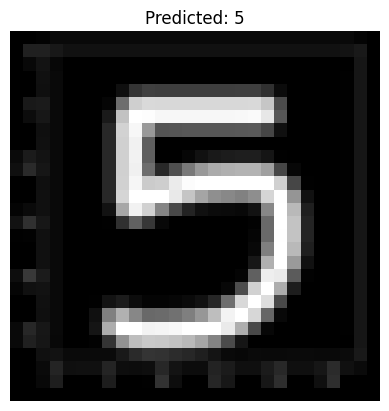

In [ ]:
from google.colab import files
from PIL import Image, ImageOps

uploaded = files.upload()  # choose an image file from your computer

def predict_custom_image(filepath, model, is_letters=False):
    img = Image.open(filepath).convert("L")   # grayscale
    img = ImageOps.invert(img)                 # light strokes on dark background, like MNIST/EMNIST
    img = img.resize((28, 28))
    arr = np.array(img).astype("float32") / 255.0
    arr = arr.reshape(1, 28, 28, 1)

    pred = model.predict(arr)
    label_idx = np.argmax(pred)

    plt.imshow(arr.squeeze(), cmap="gray")
    if is_letters:
        plt.title(f"Predicted: {idx_to_letter.get(label_idx, '?')}")
    else:
        plt.title(f"Predicted: {label_idx}")
    plt.axis("off")
    plt.show()

for fname in uploaded.keys():
    predict_custom_image(fname, mnist_model, is_letters=False)
    # Swap to the EMNIST model for letters instead:
    # predict_custom_image(fname, emnist_model, is_letters=True)


In [ ]:
def build_crnn(img_height=32, img_width=128, num_channels=1, num_classes=80):
    """
    Skeleton CRNN for word/sentence recognition.
    Input: a grayscale image of shape (img_height, img_width).
    Output: per-timestep class probabilities, meant to be decoded with CTC.
    `num_classes` should cover your full character set (letters, digits,
    punctuation, space) -- the model internally adds 1 extra class for the
    CTC "blank" token.
    """
    inputs = layers.Input(shape=(img_height, img_width, num_channels), name="image")

    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 1))(x)  # shrink height more than width to keep the sequence length

    # Reshape feature map (H', W', C) -> (W', H'*C) so width becomes the time axis
    shape = x.shape
    x = layers.Reshape((shape[2], shape[1] * shape[3]))(x)

    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)

    outputs = layers.Dense(num_classes + 1, activation="softmax", name="logits")(x)

    return models.Model(inputs, outputs, name="CRNN")

crnn_model = build_crnn()
crnn_model.summary()

# Training a CRNN requires wrapping this output with a CTC loss (using
# y_true, y_pred, input_length, and label_length), plus a word/line-level
# dataset such as IAM Handwriting. That full training loop is beyond the
# MNIST/EMNIST scope here, but this architecture is the standard starting
# point for extending single-character recognition to full words and sentences.


Model: "CRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 32, 128, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 128, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 32, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 32, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 32, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 32, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 32, 256)        │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 32, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 32, 81)         │        10,449 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 923,857 (3.52 MB)

 Trainable params: 923,857 (3.52 MB)

 Non-trainable params: 0 (0.00 B)